In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [27]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [28]:
df['TotalCharges'] = df['TotalCharges'].astype(int)

In [30]:
df['Churn'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

In [31]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        3847
Churn                  2
dtype: int64

In [32]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.265086,0.265370
std,0.368612,24.559481,30.090047,2266.790864,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.000000,0.000000
50%,0.000000,29.000000,70.350000,1394.000000,0.000000
75%,0.000000,55.000000,89.850000,3786.500000,1.000000
max,1.000000,72.000000,118.750000,8684.000000,1.000000


In [33]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151,1


In [34]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'MultipleLines' variable:  ",end=" ")
print(df['MultipleLines'].unique())

print("Categories in'InternetService' variable:",end=" " )
print(df['InternetService'].unique())

print("Categories in 'Contract' variable:     ",end=" " )
print(df['Contract'].unique())

print("Categories in 'PaymentMethod' variable:     ",end=" " )
print(df['PaymentMethod'].unique())

Categories in 'gender' variable:      ['Female' 'Male']
Categories in 'MultipleLines' variable:   ['No phone service' 'No' 'Yes']
Categories in'InternetService' variable: ['DSL' 'Fiber optic' 'No']
Categories in 'Contract' variable:      ['Month-to-month' 'One year' 'Two year']
Categories in 'PaymentMethod' variable:      ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

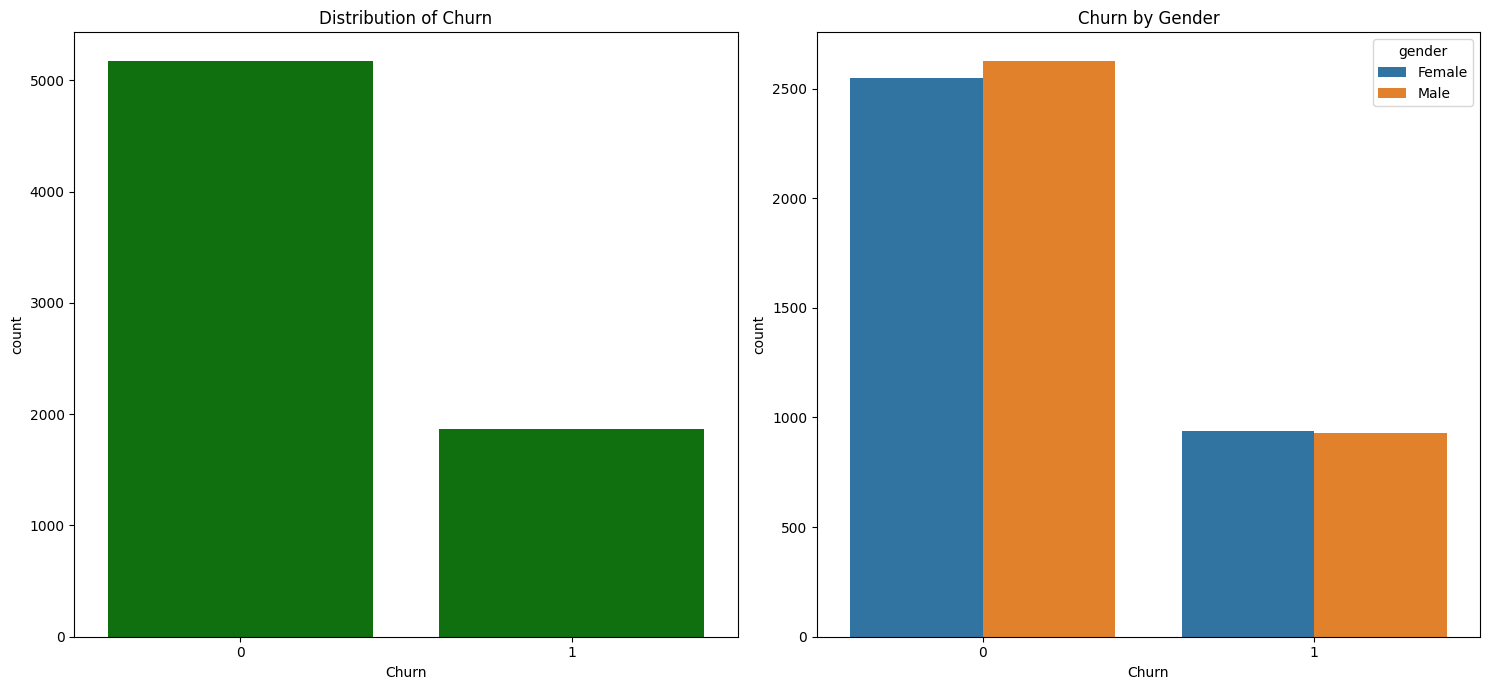

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

plt.subplot(121)
sns.countplot(data=df, x='Churn', color='g')
plt.title("Distribution of Churn")

plt.subplot(122)
sns.countplot(data=df, x='Churn', hue='gender')
plt.title("Churn by Gender")

plt.tight_layout()
plt.show()

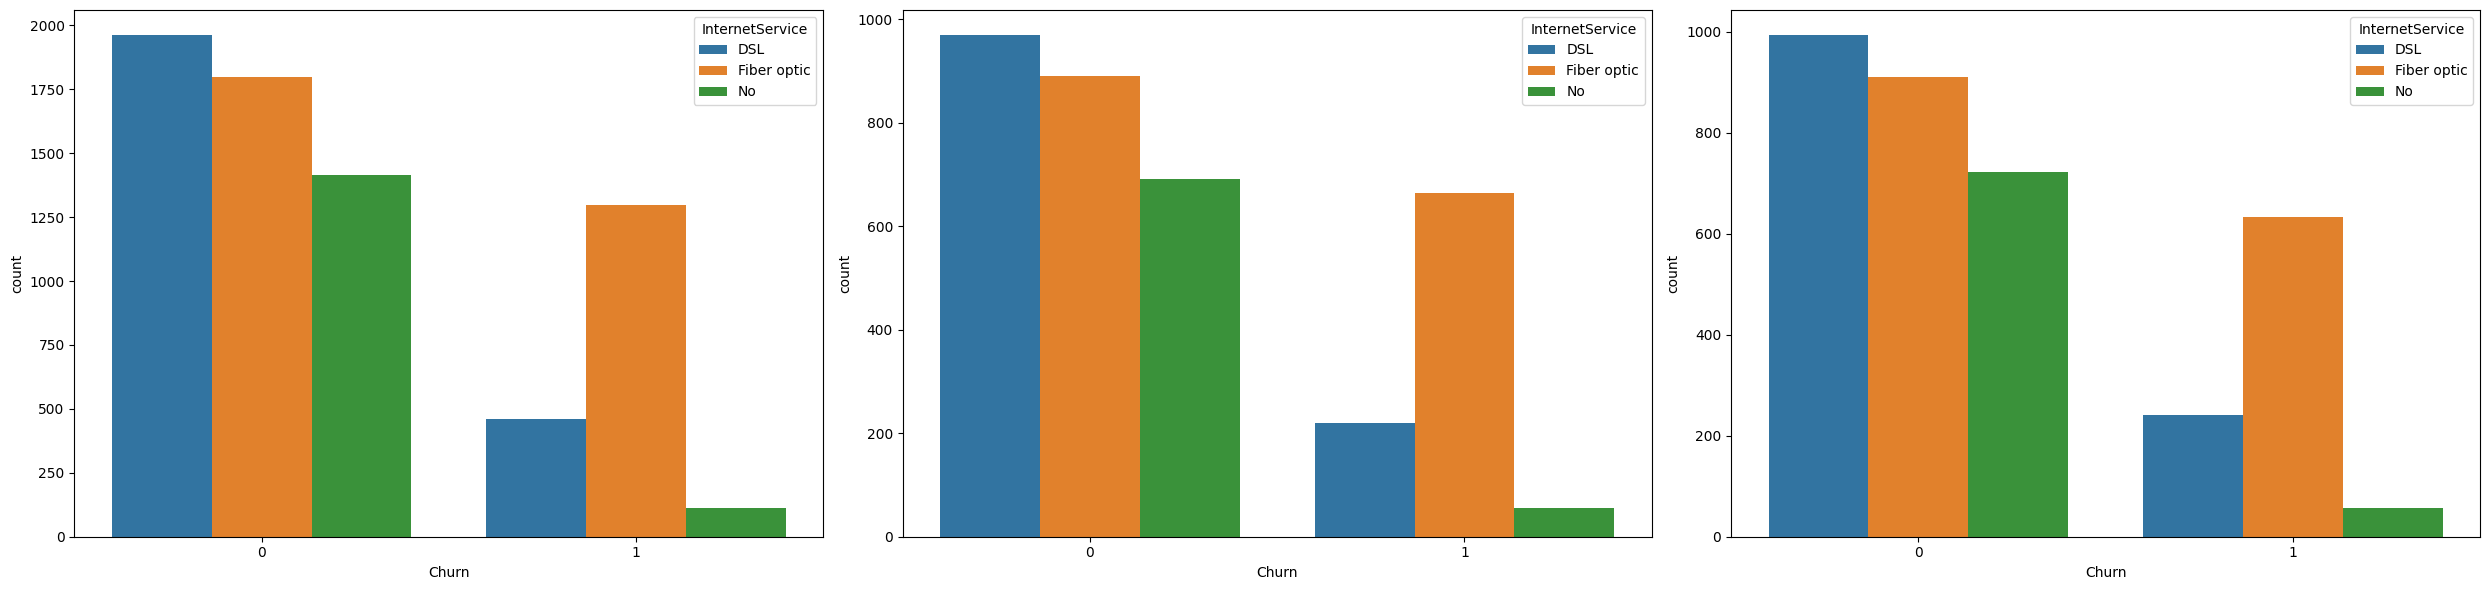

In [36]:
plt.figure(figsize=(25,6))

plt.subplot(131)
sns.countplot(data=df, x='Churn', hue='InternetService')

plt.subplot(132)
sns.countplot(data=df[df['gender']=='Female'], x='Churn', hue='InternetService')

plt.subplot(133)
sns.countplot(data=df[df['gender']=='Male'], x='Churn', hue='InternetService')

plt.tight_layout()
plt.show()

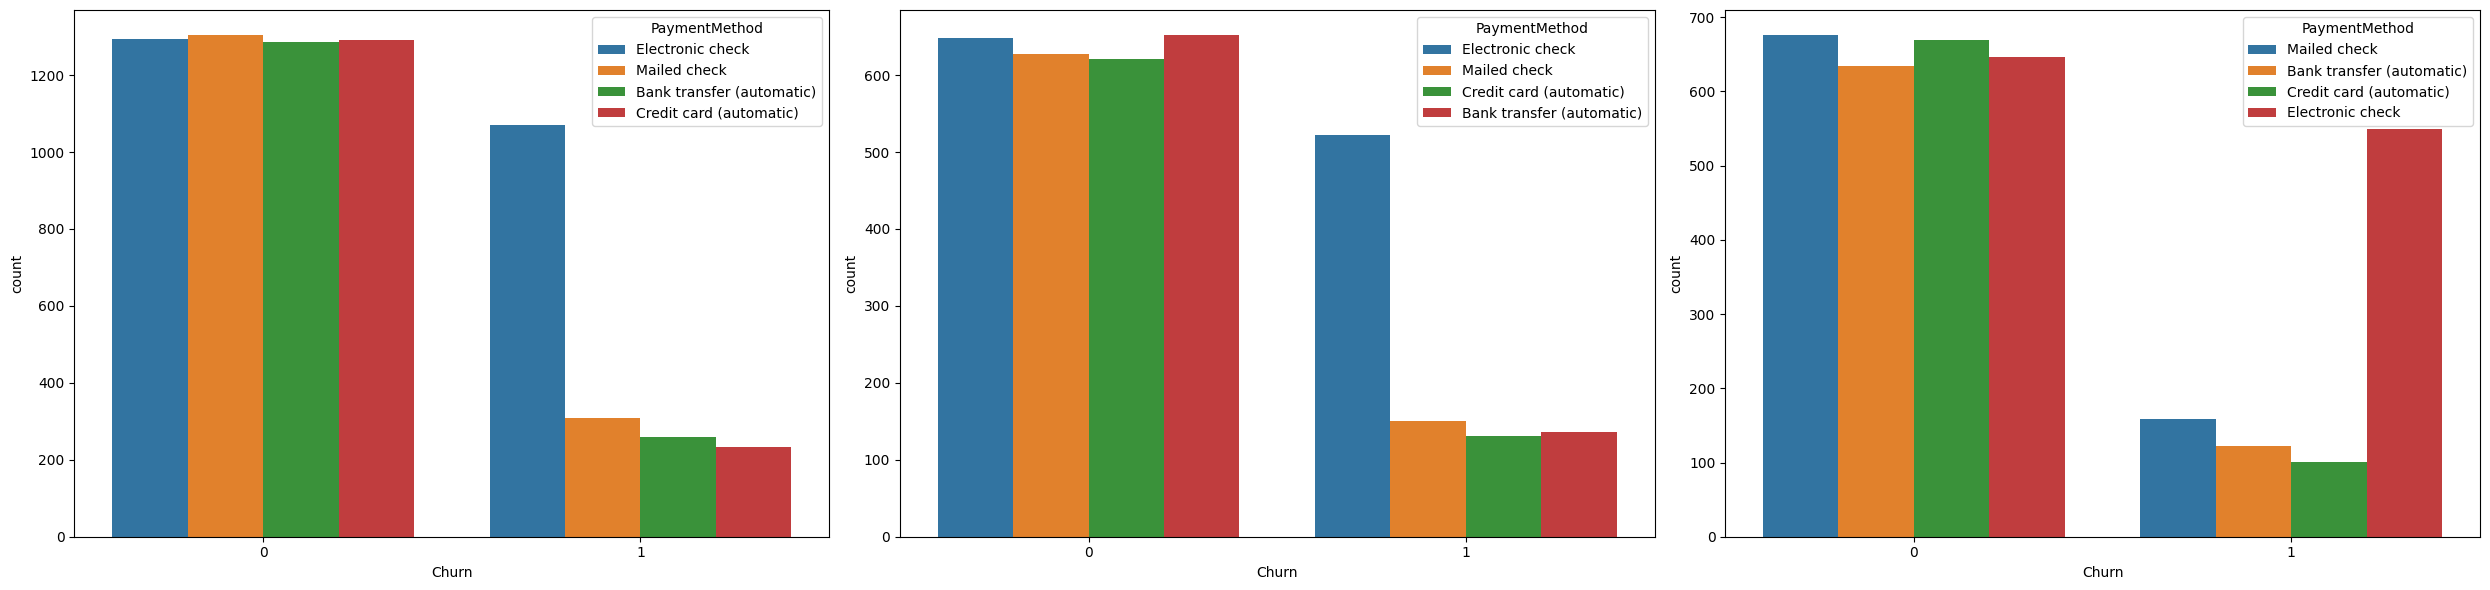

In [37]:
plt.figure(figsize=(25,6))

plt.subplot(131)
sns.countplot(data=df, x='Churn', hue='PaymentMethod')

plt.subplot(132)
sns.countplot(data=df[df['gender']=='Female'], x='Churn', hue='PaymentMethod')

plt.subplot(133)
sns.countplot(data=df[df['gender']=='Male'], x='Churn', hue='PaymentMethod')

plt.tight_layout()
plt.show()

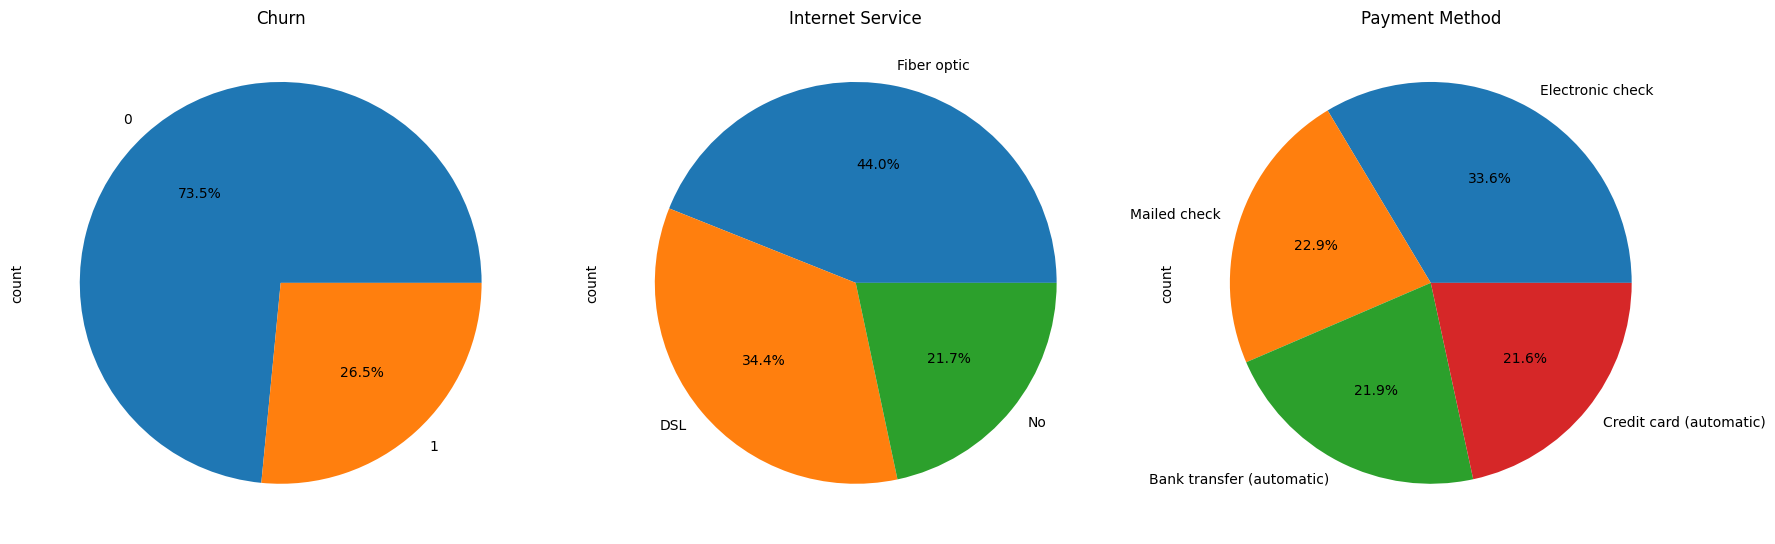

In [38]:
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Churn")

plt.subplot(1,3,2)
df['InternetService'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Internet Service")

plt.subplot(1,3,3)
df['PaymentMethod'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method")

plt.tight_layout()
plt.show()

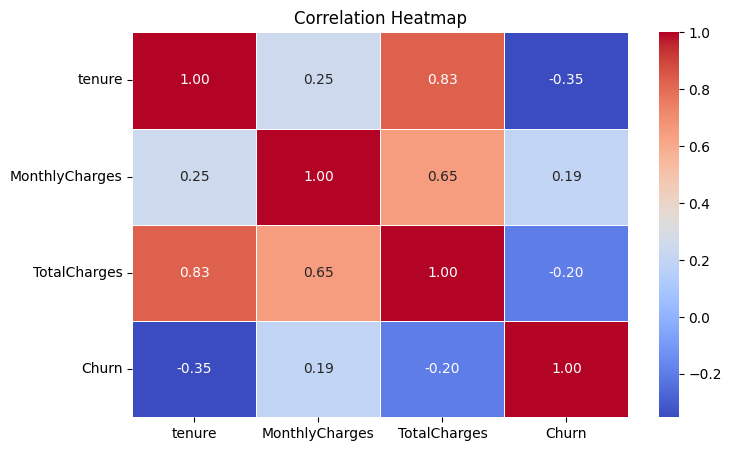

In [39]:
plt.figure(figsize=(8,5))

corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

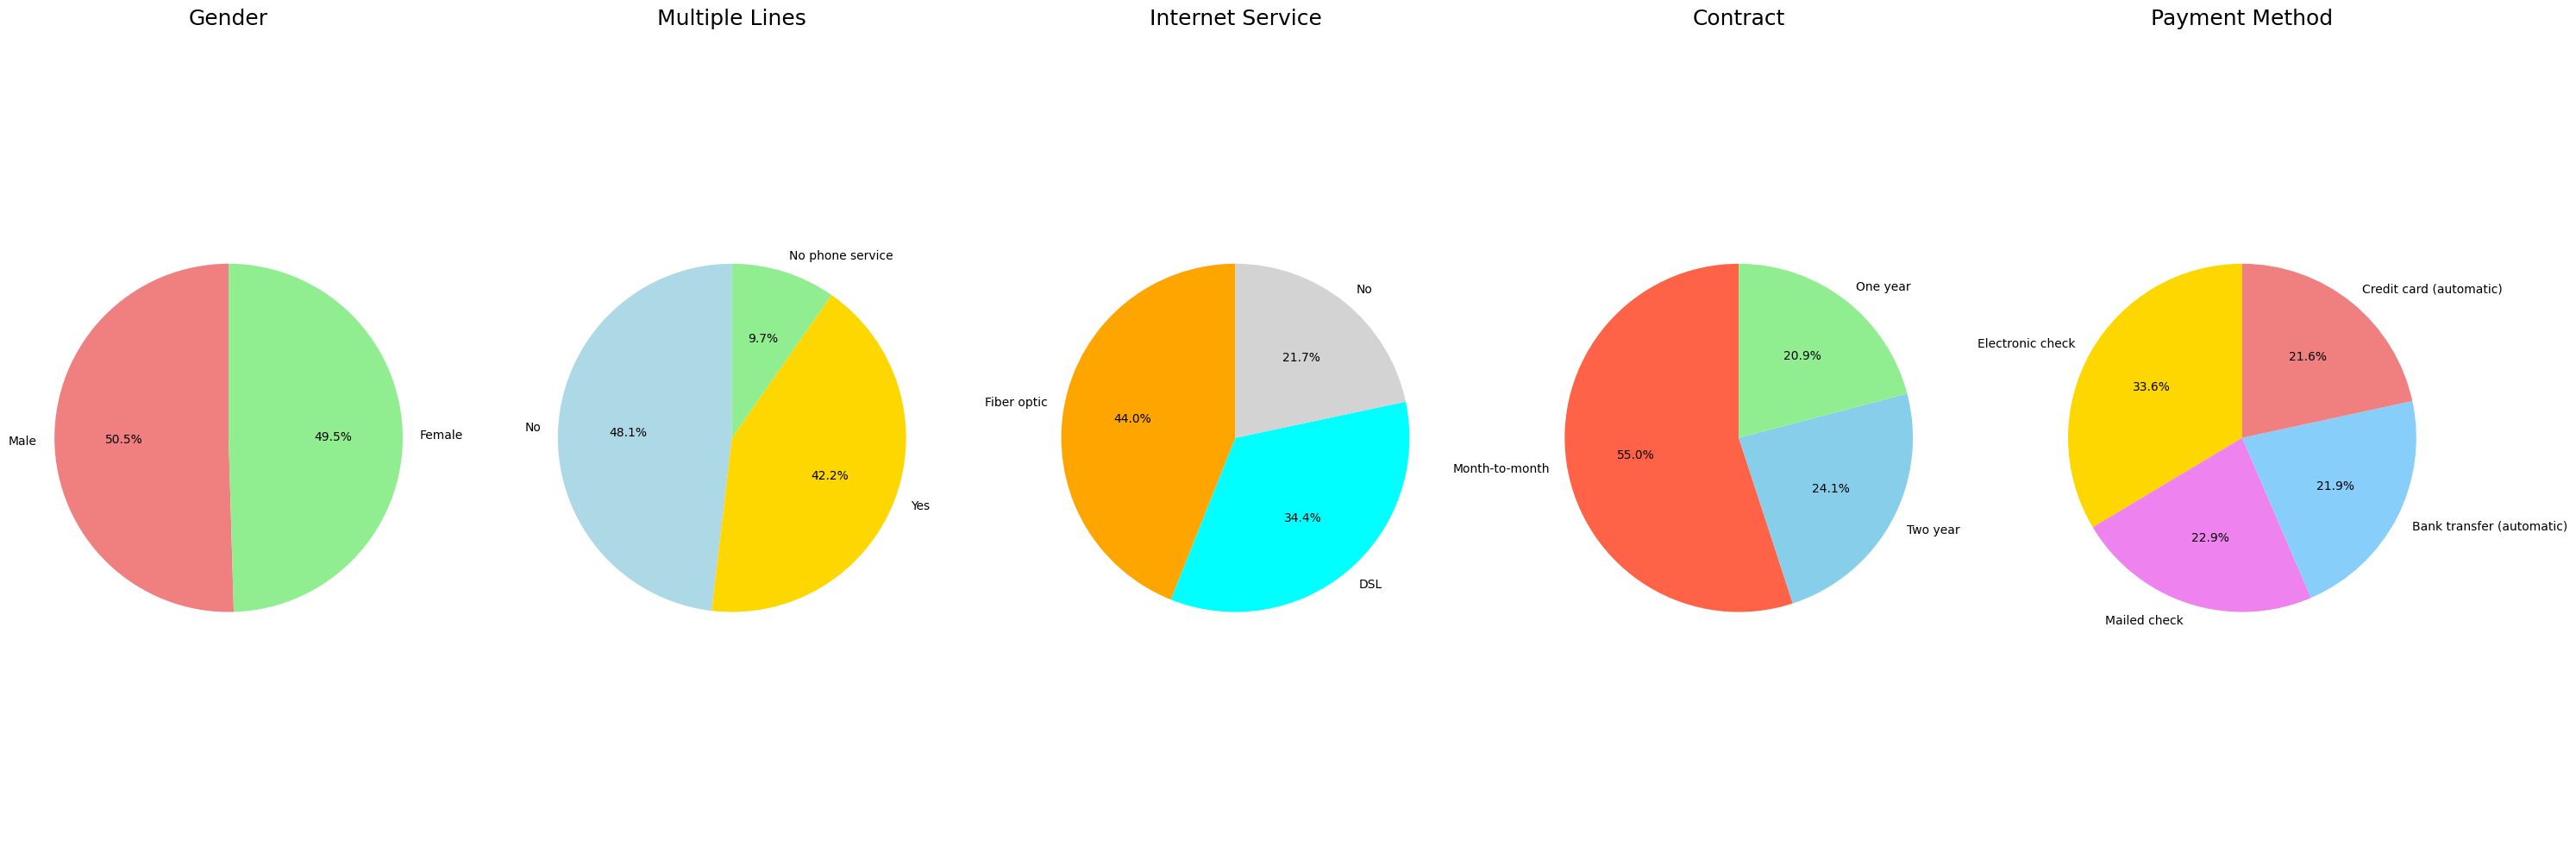

In [16]:
plt.rcParams['figure.figsize'] = (30, 10)

# Gender
plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = df['gender'].value_counts().index
colors = ['lightcoral', 'lightgreen']

plt.pie(size,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90)
plt.title('Gender', fontsize=18)
plt.axis('equal')


# Multiple Lines
plt.subplot(1, 5, 2)
size = df['MultipleLines'].value_counts()
labels = df['MultipleLines'].value_counts().index
colors = ['lightblue', 'gold', 'lightgreen']

plt.pie(size,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90)
plt.title('Multiple Lines', fontsize=18)
plt.axis('equal')


# Internet Service
plt.subplot(1, 5, 3)
size = df['InternetService'].value_counts()
labels = df['InternetService'].value_counts().index
colors = ['orange', 'cyan', 'lightgrey']

plt.pie(size,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90)
plt.title('Internet Service', fontsize=18)
plt.axis('equal')


# Contract
plt.subplot(1, 5, 4)
size = df['Contract'].value_counts()
labels = df['Contract'].value_counts().index
colors = ['tomato', 'skyblue', 'lightgreen']

plt.pie(size,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90)
plt.title('Contract', fontsize=18)
plt.axis('equal')


# Payment Method
plt.subplot(1, 5, 5)
size = df['PaymentMethod'].value_counts()
labels = df['PaymentMethod'].value_counts().index
colors = ['gold', 'violet', 'lightskyblue', 'lightcoral']

plt.pie(size,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90)
plt.title('Payment Method', fontsize=18)
plt.axis('equal')

plt.tight_layout()
plt.show()

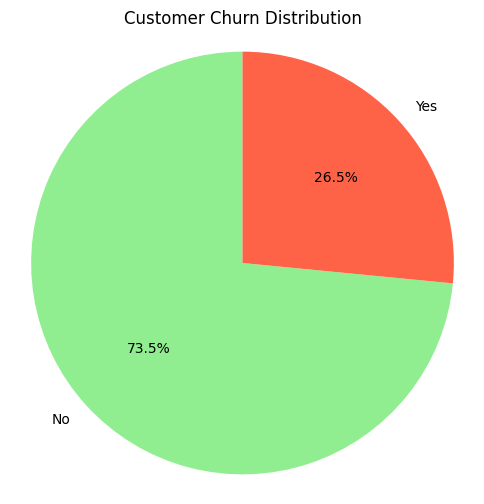

In [17]:
plt.figure(figsize=(6,6))

plt.pie(
    df['Churn'].value_counts(),
    labels=df['Churn'].value_counts().index,
    autopct='%1.1f%%',
    colors=['lightgreen', 'tomato'],
    startangle=90
)

plt.title('Customer Churn Distribution')
plt.axis('equal')
plt.show()

In [18]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,SeniorCitizen,tenure,MonthlyCharges
gender,,,
Female,0.162844,32.244553,65.204243
Male,0.161463,32.495359,64.327482


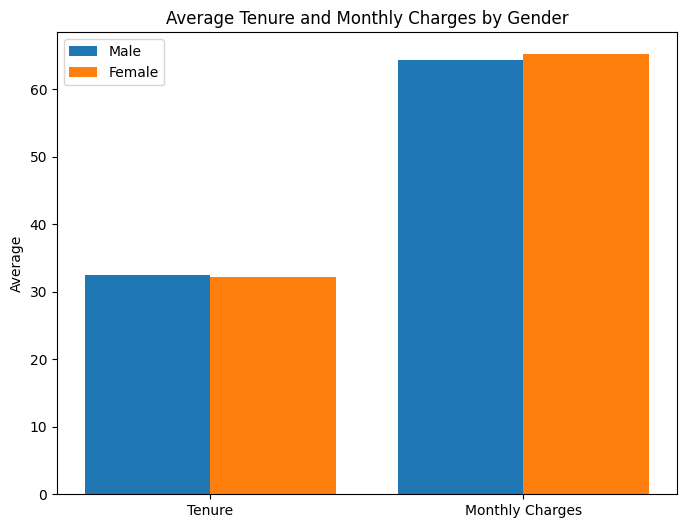

In [19]:
gender_group = df.groupby('gender')[['tenure', 'MonthlyCharges']].mean()

X = ['Tenure', 'Monthly Charges']

female_scores = gender_group.loc['Female']
male_scores = gender_group.loc['Male']

X_axis = np.arange(len(X))

plt.figure(figsize=(8,6))

plt.bar(X_axis - 0.2, male_scores, 0.4, label='Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label='Female')

plt.xticks(X_axis, X)
plt.ylabel("Average")
plt.title("Average Tenure and Monthly Charges by Gender")
plt.legend()

plt.show()

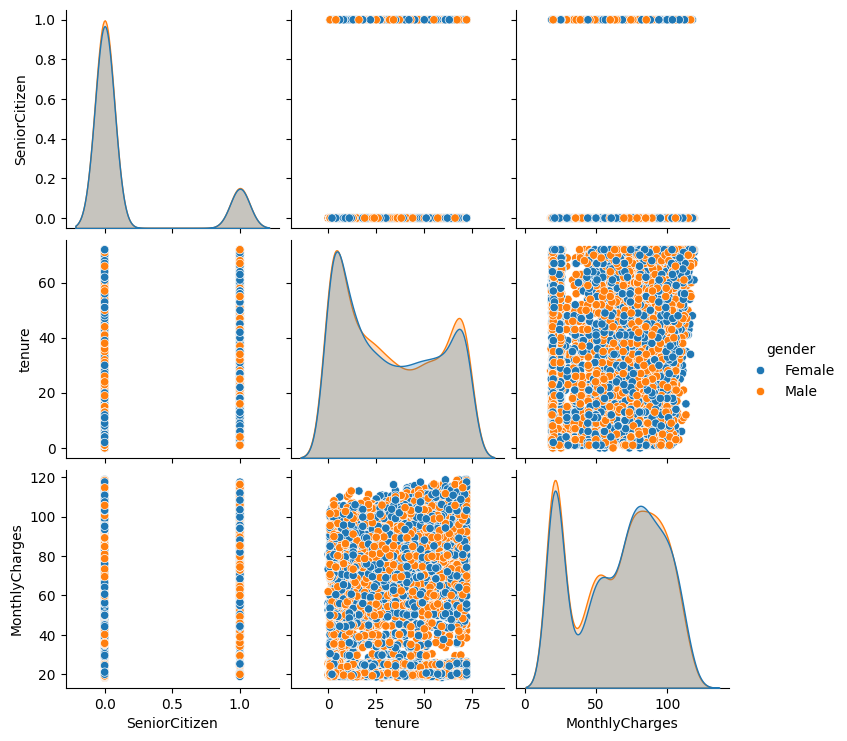

In [22]:
sns.pairplot(df,hue = 'gender')
plt.show()